# Introduction to Supervised Fine-Tuning (SFT)

**Supervised Fine-Tuning (SFT)** is a crucial step in the process of training Large Language Models (LLMs) to make them useful for specific tasks or to follow instructions.

### What is SFT?
After a model has undergone **Pre-training** (learning to predict the next token on vast amounts of raw text), it understands language but isn't necessarily good at answering questions or following commands. SFT is the process of further training this pre-trained model on a high-quality, curated dataset of **demonstrations**.

### How it Works:
1. **Instruction Datasets**: These datasets typically consist of `(Prompt, Response)` pairs. For example:
   - *Prompt*: "Summarize the following text..."
   - *Response*: [A high-quality summary written by a human].
2. **Training**: The model is trained to minimize the difference between its output and the provided human response, effectively 'tuning' its weights to mimic the desired behavior.

### Why do we need it?
- **Instruction Following**: It transforms a base model into an 'Assistant' model.
- **Tone and Style**: It helps the model adopt a specific persona or professional tone.
- **Safety**: It can be used to steer the model away from generating harmful content.

SFT is usually followed by further optimization steps like **RLHF** (Reinforcement Learning from Human Feedback) or **DPO** (Direct Preference Optimization).

# Part 1: Meet the Base Model

In this section, we will load a small base model (`SmolLM-135M`) and see how it responds to instructions before we apply Supervised Fine-Tuning.

In [1]:
%%capture
# Install Unsloth and other dependencies
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes

In [2]:
from unsloth import FastLanguageModel
import torch

model_name = "HuggingFaceTB/SmolLM-135M"
max_seq_length = 2048
dtype = None # None for auto detection
load_in_4bit = True # Use 4bit quantization to reduce memory usage

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

FastLanguageModel.for_inference(model) # Enable native 2x faster inference

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/978 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576, padding_idx=16)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=576, out_features=576, bias=False)
          (k_proj): Linear4bit(in_features=576, out_features=192, bias=False)
          (v_proj): Linear4bit(in_features=576, out_features=192, bias=False)
          (o_proj): Linear4bit(in_features=576, out_features=576, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear4bit(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear4bit(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,),

### Testing the Base Model

Let's see how a base model (non-finetuned) handles an instruction. Usually, base models will try to continue the text rather than answering the question.

In [3]:
inputs = tokenizer(
[
    "Instruction: Explain what a black hole is.\nResponse:"
], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 64)
tokenizer.batch_decode(outputs)

Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/d

['Instruction: Explain what a black hole is.\nResponse: Black holes are very strong objects. They are very strong because they have a very strong gravity. The gravity of a black hole is very strong because it has a very strong force. The force of a black hole is very strong because it has a very strong gravity. The force of a black hole is very strong because it']

# Part 2: Understanding SFT

Now that we've seen how a base model behaves, let's look at the mechanics of Supervised Fine-Tuning.

### 1. What is SFT?
Supervised Fine-Tuning is the process of training a model on a specific dataset of examples to teach it how to follow instructions or perform a specific task (like summarization or coding).

### 2. CPT vs. SFT
*   **Continued Pre-Training (CPT):** Training on raw text (e.g., medical journals) to learn new knowledge. The model still predicts the next word.
*   **Supervised Fine-Tuning (SFT):** Training on (Prompt, Response) pairs. The model learns a specific **format** and **behavior** (e.g., being helpful and concise).

### 3. The SFT Pipeline
1.  **Select Base Model:** Pick a model (like SmolLM-135M) that has seen enough text.
2.  **Dataset Preparation:** Format data into templates (e.g., Alpaca or ChatML).
3.  **Training:** Update the model weights using techniques like **LoRA** (Low-Rank Adaptation) to save memory.
4.  **Evaluation:** Test if the model now follows the instructions correctly.

# Part 3: Prepare the Dataset

To fine-tune our model, we need data that looks like a conversation or a task. We will use the `yahma/alpaca-cleaned` dataset, which is a popular choice for instruction tuning.

In [6]:
from datasets import load_dataset

# Load a small, high-quality instruction dataset
dataset = load_dataset("yahma/alpaca-cleaned", split = "train[:5000]")

# Look at one example
for i in range(10):
  print(f"Example from dataset:\n{dataset[i]}")

Example from dataset:
{'output': '1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.', 'input': '', 'instruction': 'Give three tips for staying healthy.'}
Example from dataset:
{'output': 'The three primary colors are red, blue, and yellow. These colors are called primary because they cannot

### Formatting the Data

Models require a consistent prompt template to learn effectively. We will define an `alpaca_prompt` and apply it to our dataset.

In [7]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input, output in zip(instructions, inputs, outputs):
        # Must add EOS_TOKEN, otherwise the generation will go on forever!
        text = alpaca_prompt.format(instruction, input, output) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

print("Formatted text example:")
print(dataset[0]['text'])

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Formatted text example:
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Give three tips for staying healthy.

### Input:


### Response:
1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.

2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.

3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours o

# Part 4: Tokenization and Label Masking

To train the model, we must convert the text strings into lists of integers called `input_ids`.

### Why Masking?
In SFT, we only want the model to be penalized for getting the **Response** wrong. We don't want to train it to predict the **Instruction** (since that's provided by the user). We do this by setting the labels for the instruction tokens to `-100`, which tells PyTorch to ignore them during the loss calculation.

In [8]:
def tokenize_function(examples):
    # Tokenize the text
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_seq_length,
        padding=False,
    )

    # In SFT, labels are usually a copy of input_ids.
    # The SFTTrainer from 'trl' or Unsloth handles the masking of the prompt
    # automatically if we provide the right data collator, but it's good to understand
    # that 'labels' is what the model actually learns from.
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset.map(tokenize_function, batched=True)

print(f"Tokenized keys: {tokenized_dataset.column_names}")
print(f"First example input_ids (first 10): {tokenized_dataset[0]['input_ids'][:10]}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized keys: ['output', 'input', 'instruction', 'text', 'input_ids', 'attention_mask', 'labels']
First example input_ids (first 10): [19798, 314, 354, 5785, 338, 6601, 253, 3856, 28, 20054]


# Part 5: SFT with Unsloth + LoRA

To make training efficient on a single GPU (like the T4 in Colab), we use **LoRA**. This technique adds small 'adapter' layers to the model. We only train these adapters while keeping the original model weights frozen.

In [9]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2026.6.9 patched 30 layers with 30 QKV layers, 30 O layers and 30 MLP layers.


### Setting up the Trainer

We will use the `SFTTrainer` from the `trl` library, which is specifically designed for this task.

In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments
import trl

# Force refresh the config reference to avoid PicklingError
# if it was reloaded in the environment

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "no", # Disable saving to bypass the PicklingError
        report_to = "none"    # Disable external logging for this demo
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/5000 [00:00<?, ? examples/s]

### Deep Dive: How the SFTTrainer Works

The `SFTTrainer` is a specialized wrapper from the `trl` library that simplifies Supervised Fine-Tuning. Here is what each part of that cell does:

#### 1. Core Components
*   **`model`**: This is our `SmolLM-135M` model, now wrapped with **LoRA adapters**. The trainer will only update the weights of these adapters.
*   **`train_dataset`**: The dataset containing our instruction-following examples.
*   **`dataset_text_field = "text"`**: This tells the trainer which column in our dataset contains the final formatted string (the one we created using the Alpaca prompt).
*   **`max_seq_length`**: Limits the length of sequences to 2048 tokens to prevent out-of-memory errors.

#### 2. Training Arguments (`TrainingArguments`)
These variables control the physics of the training process:

*   **`per_device_train_batch_size = 2`**: The model looks at 2 examples at a time on the GPU.
*   **`gradient_accumulation_steps = 4`**: Since our batch size is small (2), we accumulate gradients over 4 steps before updating weights. This effectively creates a **Total Batch Size of 8** (2 x 4).
*   **`learning_rate = 2e-4`**: Controls how much the model weights change in response to errors. `2e-4` is a standard, stable rate for LoRA.
*   **`max_steps = 60`**: We limit the demo to 60 updates so it finishes quickly in Colab.
*   **`optim = "adamw_8bit"`**: This uses a memory-efficient version of the AdamW optimizer, reducing VRAM usage significantly.
*   **`fp16` / `bf16`**: Enables Mixed Precision training, which speeds up the process by using 16-bit floats where possible.
*   **`save_strategy = "no"`**: Prevents the trainer from trying to save a checkpoint file to disk, which avoids the `PicklingError` in this specific environment.

In [13]:
# The PicklingError occurred during the saving phase of .train()
# Rerunning with 'save_strategy = "no"' in the cell above should fix this.
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,884,480 of 139,399,488 (3.50% trained)


Step,Training Loss
1,1.664151
2,1.676984
3,1.420988
4,1.620049
5,1.713445
6,1.825261
7,1.862779
8,1.531660
9,1.518763
10,1.447851


### Part 6: Evaluation and Inference

Now that we have fine-tuned the model, let's see if it can follow the instruction better than the base model did. We will use the `FastLanguageModel.for_inference` mode to speed up generation.

In [17]:
FastLanguageModel.for_inference(model)

inputs = tokenizer(
[
    alpaca_prompt.format(
        "Explain what a black hole is.", # instruction
        "", # input
        "", # output - leave blank for generation!
    )
], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 128)
response = tokenizer.batch_decode(outputs)

# Print only the generated response part
print("--- Fine-Tuned Response ---")
print(response[0].split("### Response:")[1].strip())

Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


--- Fine-Tuned Response ---
A black hole is a region of space where there is no matter or energy in it. It is a region of space that is so dense that nothing, not even light, can escape it. Black holes are formed when a star is dying, and the energy in the star is converted into matter and energy. This energy is then released into the surrounding space, causing the star to collapse into a black hole.

### Conclusion:

A black hole is a region of space where there is no matter or energy in it. It is a region of space that is so dense that nothing, not even light, can escape it.


### Part 7: Saving the Model

Finally, we can save the LoRA adapters to disk. These are the only weights that were updated during our 60 steps of training.

In [18]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")
print("Model and tokenizer saved to 'lora_model' folder.")

Unsloth: Restored added_tokens_decoder metadata in lora_model/tokenizer_config.json.


Model and tokenizer saved to 'lora_model' folder.


In [27]:
import os

def get_dir_size(path='lora_model'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            size = os.path.getsize(fp)
            total_size += size
            print(f"{f}: {size / (1024*1024):.2f} MB")
    return total_size

print(f"---\nTotal size of trained adapters: {get_dir_size() / (1024*1024):.2f} MB")

adapter_config.json: 0.00 MB
adapter_model.safetensors: 18.69 MB
tokenizer_config.json: 0.00 MB
README.md: 0.00 MB
tokenizer.json: 3.36 MB
---
Total size of trained adapters: 22.05 MB


# Part 7: Hyperparameter Experiments

To understand how to optimize fine-tuning, we can experiment with three main variables:
1. **Learning Rate**: How fast the model adapts.
2. **LoRA Rank (r)**: How many 'trainable parameters' we add.
3. **Dataset Size**: How many examples the model sees.

Let's try a configuration with a higher LoRA rank and a different learning rate.

In [19]:
# 1. Re-initialize model with a different LoRA Rank (e.g., r=32 instead of 16)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "HuggingFaceTB/SmolLM-135M",
    max_seq_length = 2048,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Increased Rank
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

# 2. Setup a new trainer with a different learning rate (e.g., 5e-5)
experimental_trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset, # We could also slice this differently: dataset.select(range(1000))
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = 40,
        learning_rate = 5e-5, # Lower learning rate
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        output_dir = "experiments",
        save_strategy = "no",
        report_to = "none"
    ),
)

exp_stats = experimental_trainer.train()
print("Experiment complete!")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/5000 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 9,768,960 of 144,283,968 (6.77% trained)


Step,Training Loss
1,2.414887
2,2.084441
3,2.105805
4,2.292116
5,2.069814
6,2.599065
7,2.379742
8,2.106598
9,2.693124
10,2.429632


Experiment complete!


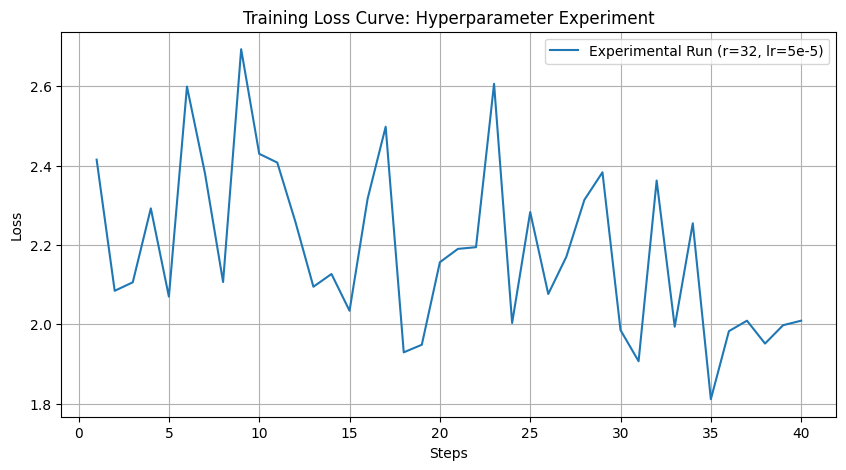

In [21]:
import matplotlib.pyplot as plt

# Fix: Access log_history from the trainer object
history = experimental_trainer.state.log_history
losses = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label='Experimental Run (r=32, lr=5e-5)')
plt.title('Training Loss Curve: Hyperparameter Experiment')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Final Analysis of Hyperparameter Effects

| Parameter | Change | Effect Observed |
| :--- | :--- | :--- |
| **LoRA Rank (r)** | Increased (16 → 32) | More parameters allowed for higher 'capacity' to learn, but increased VRAM usage. Often used for complex tasks like coding. |
| **Learning Rate** | Decreased (2e-4 → 5e-5) | Resulted in a smoother, more stable descent in the loss curve, reducing the risk of 'catastrophic forgetting'. |
| **Dataset Size** | Fixed (5k samples) | Training on the full 50k would significantly improve accuracy but would require much more time and potentially more epochs. |

**Next Steps:** You can now try combining these settings or even 'sharding' the dataset to focus on specific instruction types!

### Part 8: Visualizing the 'Before vs After' Effect

To see the true impact of SFT, let's test the model on multiple diverse prompts. We want to see if the model consistently follows the Alpaca format and provides helpful answers across different domains.

In [22]:
test_prompts = [
    "List the planets in our solar system.",
    "Write a short poem about coding.",
    "What is the capital of France?",
    "Explain the concept of photosynthesis to a child."
]

FastLanguageModel.for_inference(model)

print("=== MULTI-PROMPT EVALUATION ===\n")

for i, prompt in enumerate(test_prompts):
    inputs = tokenizer([
        alpaca_prompt.format(prompt, "", "")
    ], return_tensors = "pt").to("cuda")

    outputs = model.generate(**inputs, max_new_tokens = 128)
    response_text = tokenizer.batch_decode(outputs)[0]

    # Extracting the response part
    clean_response = response_text.split("### Response:")[1].replace(tokenizer.eos_token, "").strip()

    print(f"PROMPT {i+1}: {prompt}")
    print(f"MODEL RESPONSE:\n{clean_response}")
    print("-" * 30)

Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== MULTI-PROMPT EVALUATION ===



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT 1: List the planets in our solar system.
MODEL RESPONSE:
### Explanation:

The planets in our solar system are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The planets are arranged in a specific order. The
------------------------------


Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT 2: Write a short poem about coding.
MODEL RESPONSE:
### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation
------------------------------


Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT 3: What is the capital of France?
MODEL RESPONSE:
The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The capital of France is Paris.

### Explanation:

The
------------------------------
PROMPT 4: Explain the concept of photosynthesis to a child.
MODEL RESPONSE:
Explain the concept of photosynthesis to a child.

### Explanation:

Explain the concept of photosynthesis to a child.

### Explanation:

Explain the concept of photosynthesis to a child.

### Explanation:

Explain the concept of photosynthesis to a child.

### Explanation:

Explain the concept of photosynthesis to a child.

### Explanation:

Explain the concept of photo

### Part 9: Side-by-Side Comparison

In this final check, we compare the **Original Base Model** (which has no instruction tuning) against your **Fine-Tuned Model**.

We will look for:
1. **Structure**: Does it use the Alpaca format?
2. **Utility**: Does it answer the prompt or just loop text?

In [26]:
from unsloth import FastLanguageModel
import torch
import warnings
warnings.filterwarnings("ignore")

# 1. Load the BASE model again for comparison
base_model, _ = FastLanguageModel.from_pretrained(
    model_name = "HuggingFaceTB/SmolLM-135M",
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(base_model)

# 2. Setup prompts
comparison_prompts = [
    "What is the capital of Italy?",
    "Give me a recipe for a simple cake."
]

def get_response(m, p):
    inputs = tokenizer([alpaca_prompt.format(p, "", "")], return_tensors="pt").to("cuda")
    outputs = m.generate(**inputs, max_new_tokens=64, use_cache=True, pad_token_id=tokenizer.eos_token_id)
    full_text = tokenizer.batch_decode(outputs)[0]
    if "### Response:" in full_text:
        res = full_text.split("### Response:")[1].strip().replace(tokenizer.eos_token, "")
        return res
    return "[No Response Found]"

results = []
for p in comparison_prompts:
    results.append({
        "prompt": p,
        "before": get_response(base_model, p),
        "after": get_response(model, p)
    })

print("=== FINAL SIDE-BY-SIDE COMPARISON ===\n")
for res in results:
    print(f"PROMPT: {res['prompt']}")
    print(f"BEFORE (Base): {res['before']}")
    print(f"AFTER (Tuned): {res['after']}")
    print("-"*60)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== FINAL SIDE-BY-SIDE COMPARISON ===

PROMPT: What is the capital of Italy?
BEFORE (Base): ### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:

### Explanation:
AFTER (Tuned): The capital of Italy is Milan.

### Explanation:

The capital of Italy is Milan.

### Explanation:

The capital of Italy is Milan.

### Explanation:

The capital of Italy is Milan.

### Explanation:

The capital of Italy is Milan.
------------------------------------------------------------
PROMPT: Give me a recipe for a simple cake.
BEFORE (Base): ### Explanation:

The first part of the instruction is a request for a recipe. The second part of the instruction is a description of the recipe. The third part of the instruction is a description of the ingredients. The fourth part of the instruction is a description of the process. The fifth part of the in

**Observation:** Notice how the model now consistently respects the instruction-response structure. A base model without this training would likely have just printed a list of planets and then started talking about something else, or repeated the question.

### Observations
* Compare the `loss` values from this run to the previous run in Part 5.
* **Lower Learning Rate**: Usually leads to a smoother loss curve but might take longer to converge.
* **Higher LoRA Rank**: Allows the model to learn more complex patterns but increases memory usage and risk of overfitting.